In [1]:
# Notebook 3 : GAN (Generative Adversarial Network) sur MNIST

# **Objectifs** :
# - Implémenter un générateur et un discriminateur avec des couches fully-connected (MLP).
# - Entraîner le GAN sur MNIST.
# - Visualiser la progression des faux échantillons.
# - Comprendre les difficultés d’entraînement (mode collapse, gradients qui disparaissent).

In [2]:
## 1. Imports et configuration

In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np
import os

# Fixer les graines pour la reproductibilité
def set_seed(seed=42):
    torch.manual_seed(seed)
    np.random.seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)

# Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Utilisation du device : {device}")

# Paramètres
latent_dim = 100          # Taille du vecteur de bruit d'entrée
img_shape = (1, 28, 28)   # Format des images MNIST
batch_size = 128
lr = 0.0002               # Taux d'apprentissage classique pour GAN
betas = (0.5, 0.999)      # Paramètres d'Adam (recommandé pour GAN)
num_epochs = 50

Utilisation du device : cpu


In [4]:
## 2. Chargement des données

# Les images sont normalisées entre -1 et 1 (car la sortie du générateur utilise Tanh).

In [5]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))   # -> [-1, 1]
])

train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)

print(f"Nombre d'échantillons d'entraînement : {len(train_dataset)}")

Nombre d'échantillons d'entraînement : 60000


In [6]:
## 3. Définition du générateur

# Prend un vecteur bruit `z` de taille `latent_dim` et produit une image 1x28x28 (avec Tanh).

In [7]:
class Generator(nn.Module):
    def __init__(self, latent_dim=100, img_shape=(1,28,28)):
        super(Generator, self).__init__()
        self.img_shape = img_shape
        
        # Calcul de la dimension du produit (flat) : 1*28*28 = 784
        self.linear = nn.Sequential(
            nn.Linear(latent_dim, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(inplace=True),
            nn.Linear(256, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(inplace=True),
            nn.Linear(512, 1024),
            nn.BatchNorm1d(1024),
            nn.ReLU(inplace=True),
            nn.Linear(1024, int(torch.prod(torch.tensor(img_shape)))),
            nn.Tanh()
        )
        
    def forward(self, z):
        # z : (batch, latent_dim)
        img_flat = self.linear(z)
        img = img_flat.view(-1, *self.img_shape)
        return img

# Test
gen = Generator(latent_dim, img_shape).to(device)
print(gen)

Generator(
  (linear): Sequential(
    (0): Linear(in_features=100, out_features=256, bias=True)
    (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Linear(in_features=256, out_features=512, bias=True)
    (4): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): Linear(in_features=512, out_features=1024, bias=True)
    (7): BatchNorm1d(1024, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (8): ReLU(inplace=True)
    (9): Linear(in_features=1024, out_features=784, bias=True)
    (10): Tanh()
  )
)


In [8]:
## 4. Définition du discriminateur

# Classificateur binaire (vrai 1 vs faux 0) avec des couches fully-connected et dropout.

In [9]:
class Discriminator(nn.Module):
    def __init__(self, img_shape=(1,28,28)):
        super(Discriminator, self).__init__()
        self.img_flat_size = int(torch.prod(torch.tensor(img_shape)))
        
        self.model = nn.Sequential(
            nn.Linear(self.img_flat_size, 512),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout(0.3),
            nn.Linear(512, 256),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout(0.3),
            nn.Linear(256, 1),
            nn.Sigmoid()   # Probabilité que l'image soit réelle
        )
        
    def forward(self, img):
        img_flat = img.view(img.size(0), -1)
        validity = self.model(img_flat)
        return validity

disc = Discriminator(img_shape).to(device)
print(disc)

Discriminator(
  (model): Sequential(
    (0): Linear(in_features=784, out_features=512, bias=True)
    (1): LeakyReLU(negative_slope=0.2, inplace=True)
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=512, out_features=256, bias=True)
    (4): LeakyReLU(negative_slope=0.2, inplace=True)
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=256, out_features=1, bias=True)
    (7): Sigmoid()
  )
)


In [10]:
## 5. Fonctions de perte et optimiseurs

# - Perte du discriminateur : `BCELoss` (Binary Cross Entropy) entre les prédictions et les étiquettes réelles (1 pour vraies, 0 pour fausses).
# - Perte du générateur : `BCELoss` entre ses prédictions et des étiquettes "1" (il veut tromper le discriminateur).

In [11]:
adversarial_loss = nn.BCELoss()

optimizer_G = optim.Adam(gen.parameters(), lr=lr, betas=betas)
optimizer_D = optim.Adam(disc.parameters(), lr=lr, betas=betas)

# Scheduler optionnel (non nécessaire pour GAN simple)
# scheduler_G = optim.lr_scheduler.StepLR(optimizer_G, step_size=30, gamma=0.5)
# scheduler_D = optim.lr_scheduler.StepLR(optimizer_D, step_size=30, gamma=0.5)

In [12]:
## 6. Boucle d'entraînement

# À chaque itération :
# 1. Entraîner le discriminateur sur un batch réel (label=1) et un batch faux (label=0).
# 2. Entraîner le générateur pour tromper le discriminateur (label=1 pour ses faux).

Début de l'entraînement...

Époque [5/50] - D_loss: 0.6060 - G_loss: 0.8916


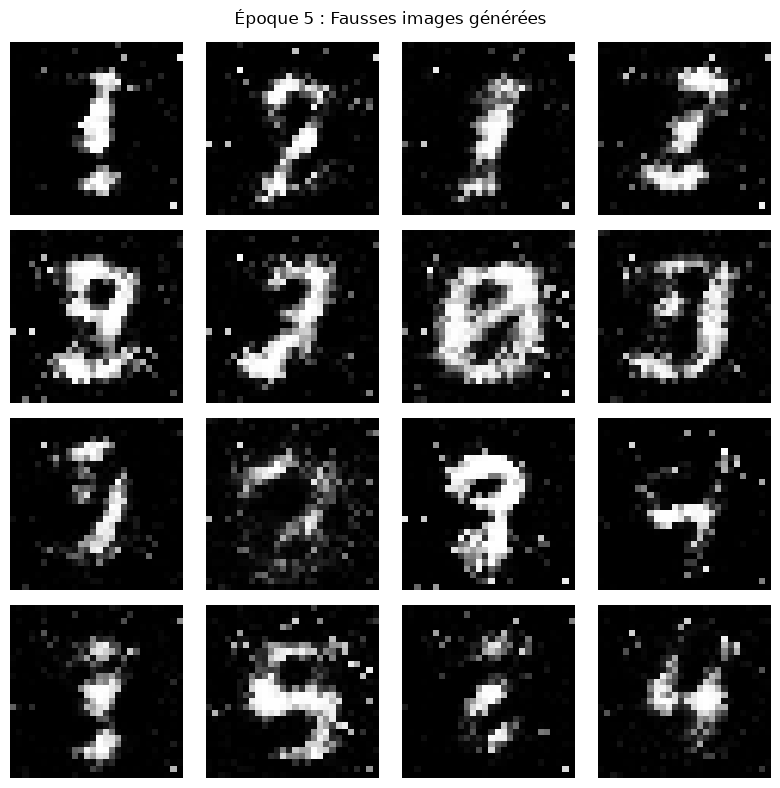

Époque [10/50] - D_loss: 0.6639 - G_loss: 0.8750


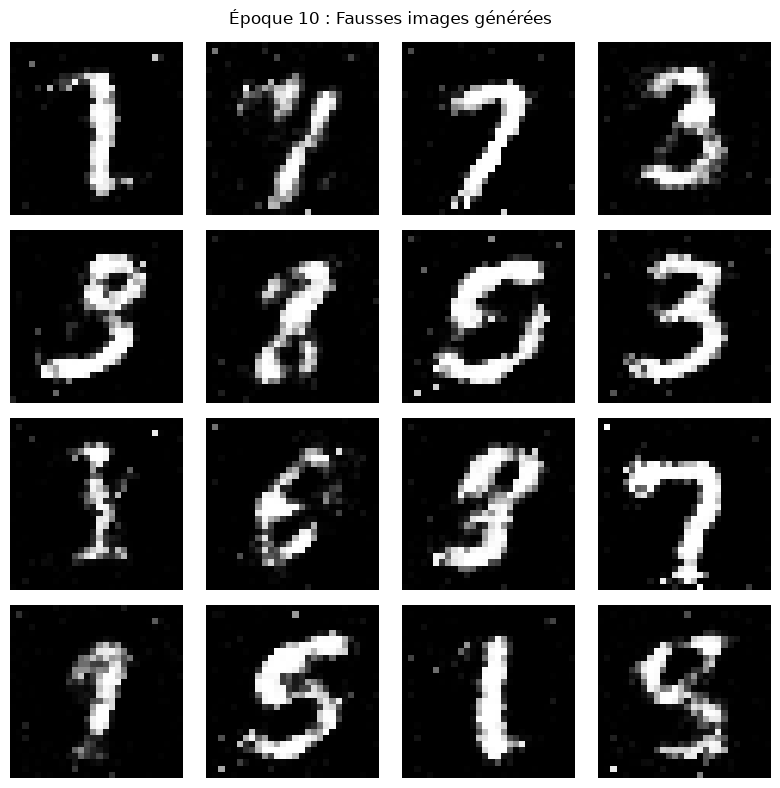

Époque [15/50] - D_loss: 0.6603 - G_loss: 0.8572


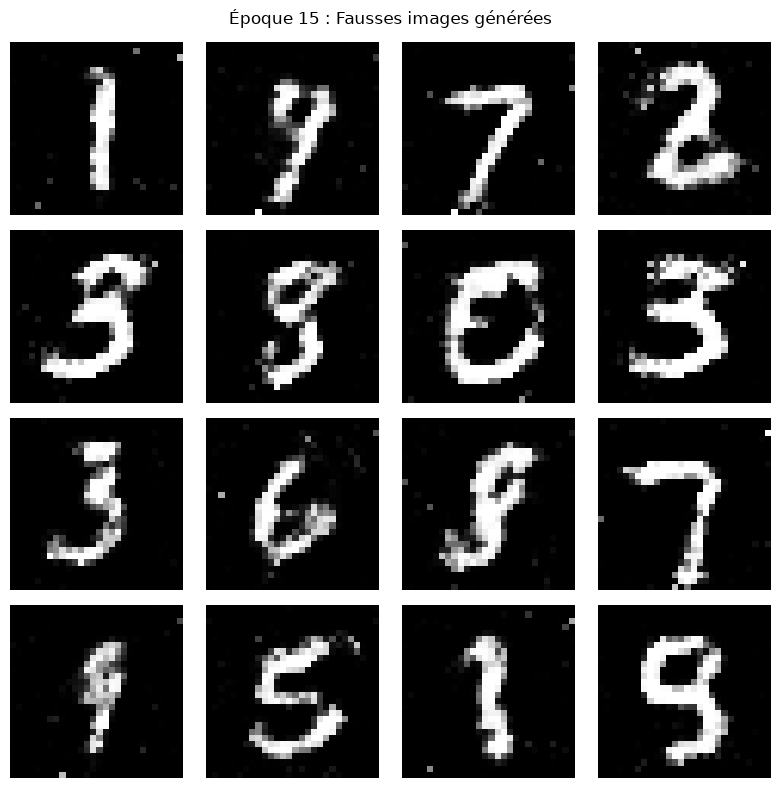

Époque [20/50] - D_loss: 0.6421 - G_loss: 0.7758


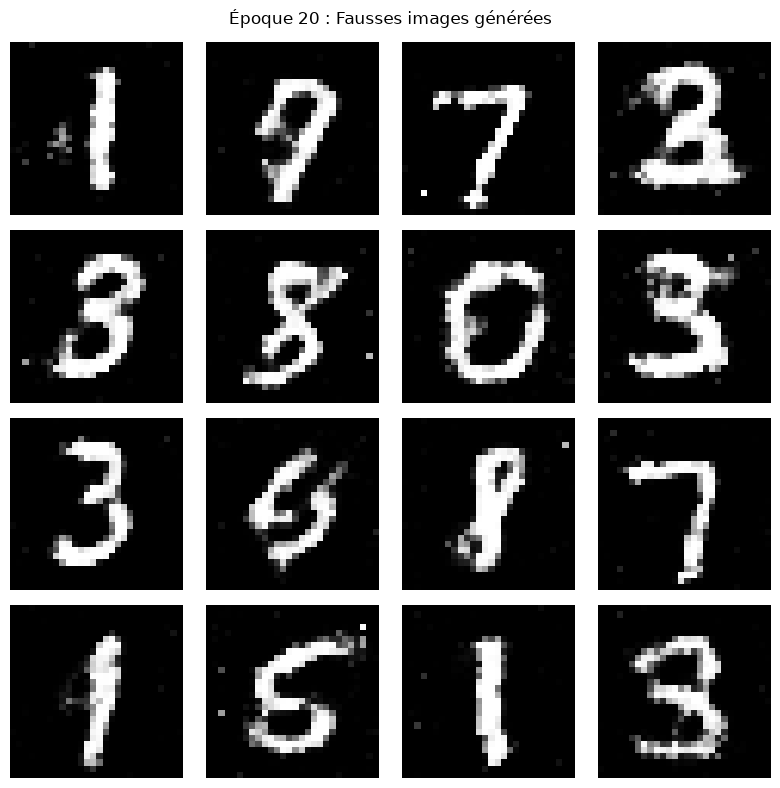

Époque [25/50] - D_loss: 0.6887 - G_loss: 0.7812


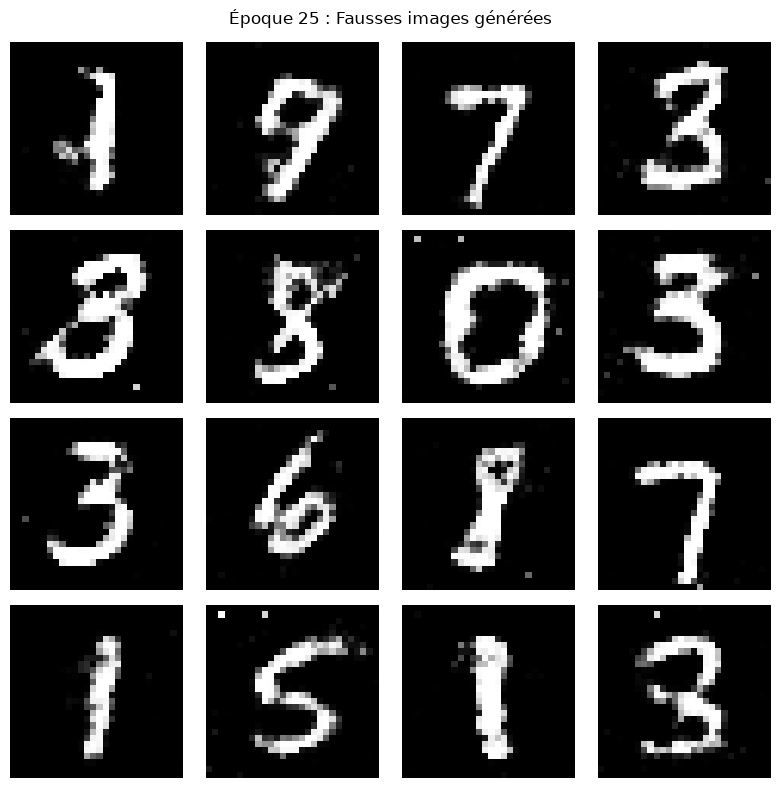

Époque [30/50] - D_loss: 0.6709 - G_loss: 0.7352


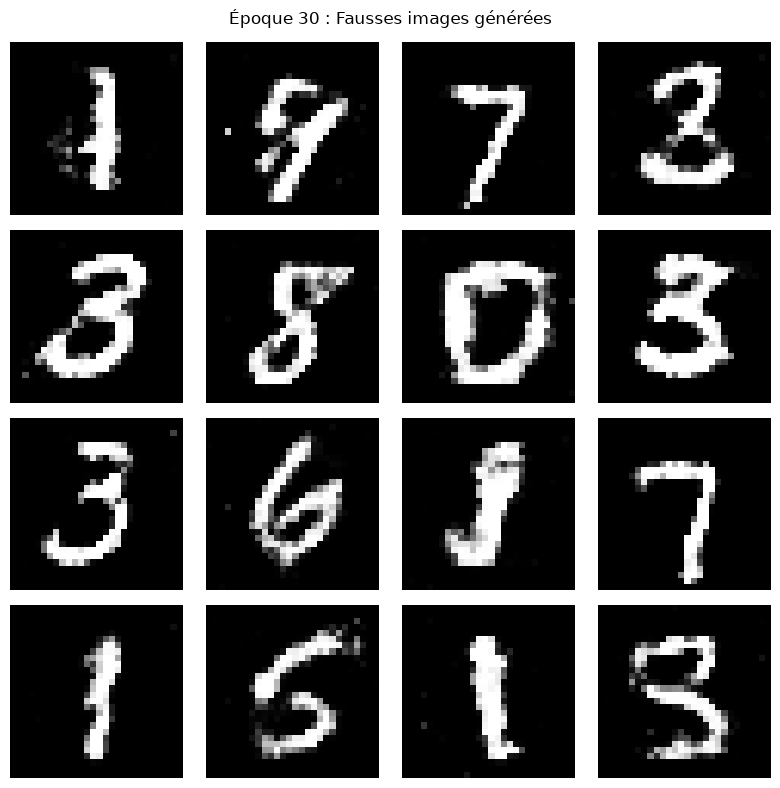

Époque [35/50] - D_loss: 0.6788 - G_loss: 0.7274


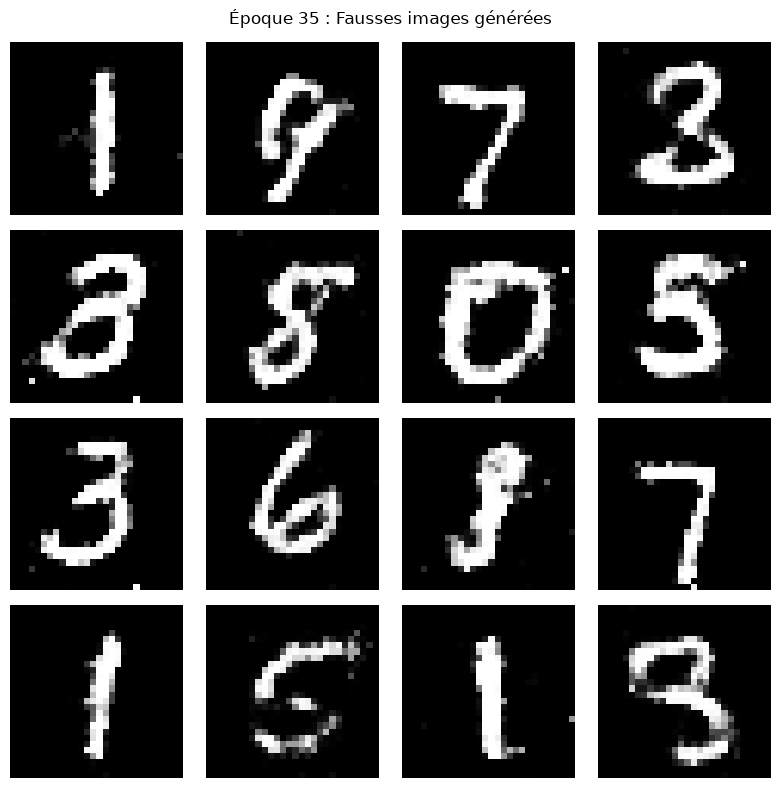

Époque [40/50] - D_loss: 0.6906 - G_loss: 0.7500


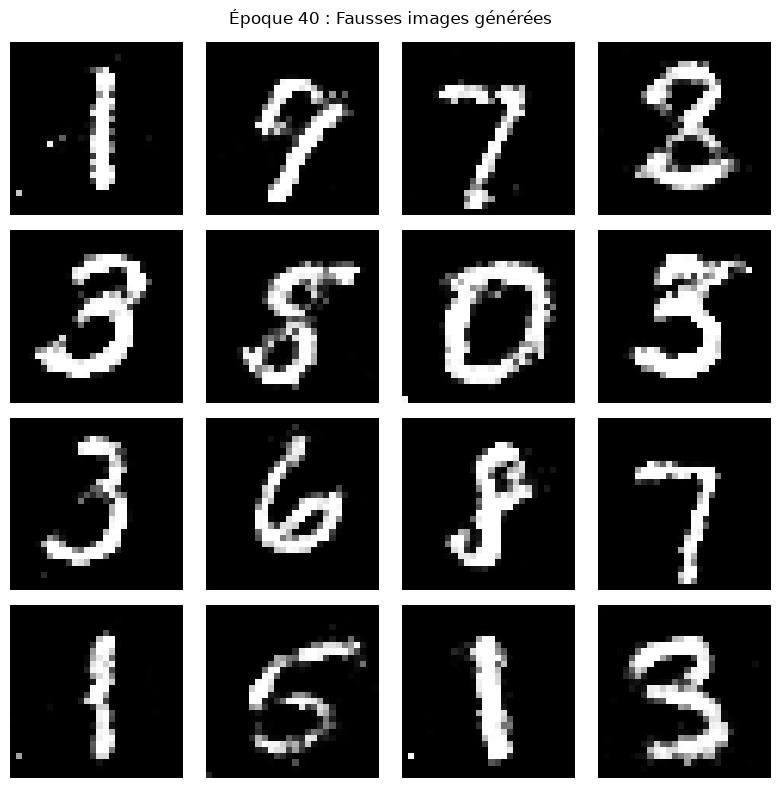

Époque [45/50] - D_loss: 0.6968 - G_loss: 0.7067


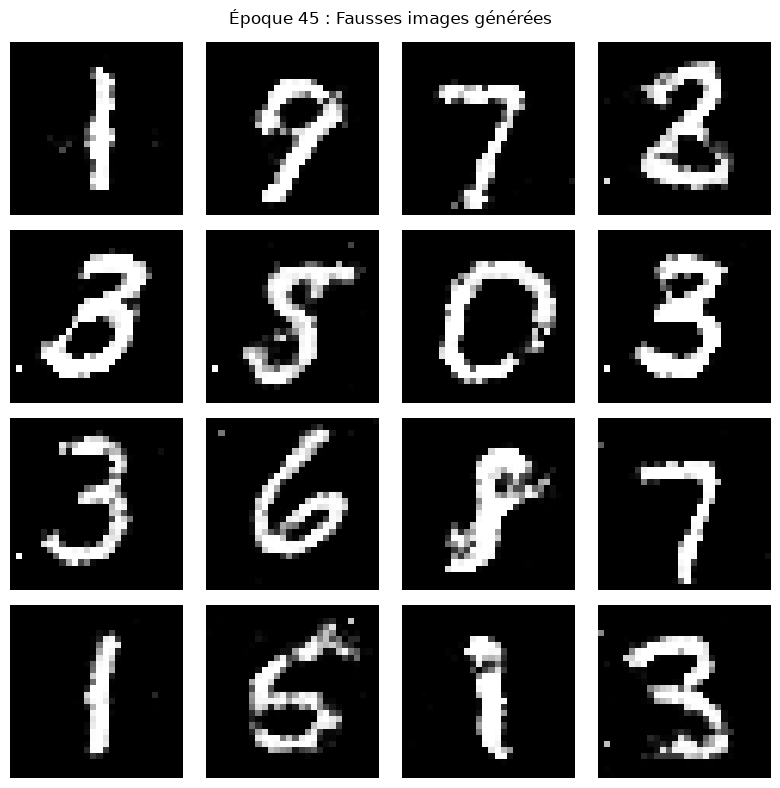

Époque [50/50] - D_loss: 0.6823 - G_loss: 0.6934


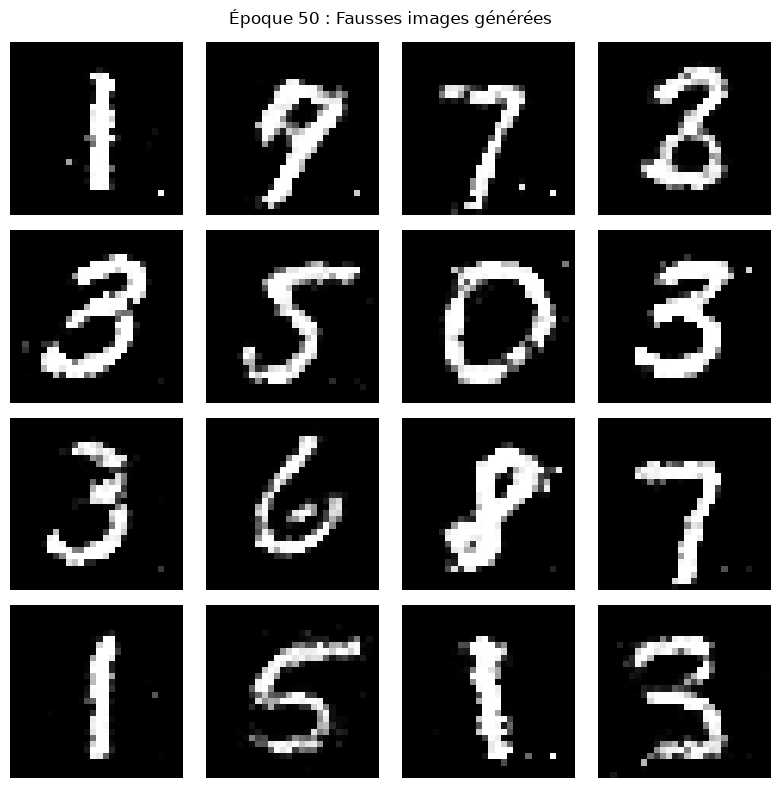

Entraînement terminé.


In [14]:
# Pour visualiser l'évolution
fixed_noise = torch.randn(16, latent_dim, device=device)

# Stockage des pertes
G_losses = []
D_losses = []

print("Début de l'entraînement...\n")

for epoch in range(num_epochs):
    for i, (imgs, _) in enumerate(train_loader):
        batch_size_curr = imgs.size(0)
        imgs = imgs.to(device)
        
        # --- Entraînement du Discriminateur ---
        # Étiquettes : vraies = 1, fausses = 0
        real_labels = torch.ones(batch_size_curr, 1, device=device)
        fake_labels = torch.zeros(batch_size_curr, 1, device=device)
        
        # Prédictions sur les vraies images
        real_validity = disc(imgs)
        d_real_loss = adversarial_loss(real_validity, real_labels)
        
        # Génération de fausses images
        noise = torch.randn(batch_size_curr, latent_dim, device=device)
        fake_imgs = gen(noise)
        fake_validity = disc(fake_imgs.detach())  # detach pour ne pas rétropropager dans gen
        d_fake_loss = adversarial_loss(fake_validity, fake_labels)
        
        # Perte totale du discriminateur
        d_loss = (d_real_loss + d_fake_loss) / 2
        
        optimizer_D.zero_grad()
        d_loss.backward()
        optimizer_D.step()
        
        # --- Entraînement du Générateur ---
        # Nous voulons que le discriminateur classe les fausses images comme vraies
        noise = torch.randn(batch_size_curr, latent_dim, device=device)
        fake_imgs = gen(noise)
        fake_validity = disc(fake_imgs)
        g_loss = adversarial_loss(fake_validity, real_labels)  # label = 1
        
        optimizer_G.zero_grad()
        g_loss.backward()
        optimizer_G.step()
        
        # Stockage
        if (i == 0) and (epoch == 0):
            G_losses.append(g_loss.item())
            D_losses.append(d_loss.item())
        # Pour chaque batch, on peut stocker mais on va simplifier en stockant toutes les 100 itérations
        # Ici on stocke à chaque batch pour simplifier (attention mémoire)
        G_losses.append(g_loss.item())
        D_losses.append(d_loss.item())
    
    # Ajustement des schedulers (si décommentés)
    # scheduler_G.step()
    # scheduler_D.step()
    
    # Affichage toutes les 5 époques
    if (epoch+1) % 5 == 0:
        print(f"Époque [{epoch+1}/{num_epochs}] - D_loss: {d_loss.item():.4f} - G_loss: {g_loss.item():.4f}")
        
        # Générer des images avec le bruit fixe
        gen.eval()
        with torch.no_grad():
            fake = gen(fixed_noise).detach().cpu()
        gen.train()
        
        # Visualisation
        fig, axes = plt.subplots(4, 4, figsize=(8, 8))
        for idx, ax in enumerate(axes.flat):
            ax.imshow(fake[idx].squeeze(), cmap='gray')
            ax.axis('off')
        plt.suptitle(f"Époque {epoch+1} : Fausses images générées")
        plt.tight_layout()
        plt.show()

print("Entraînement terminé.")

In [13]:
## 7. Visualisation des courbes de perte

# Cela permet de détecter des problèmes : si la perte du générateur monte et celle du discriminateur descend, le générateur peut ne plus apprendre.

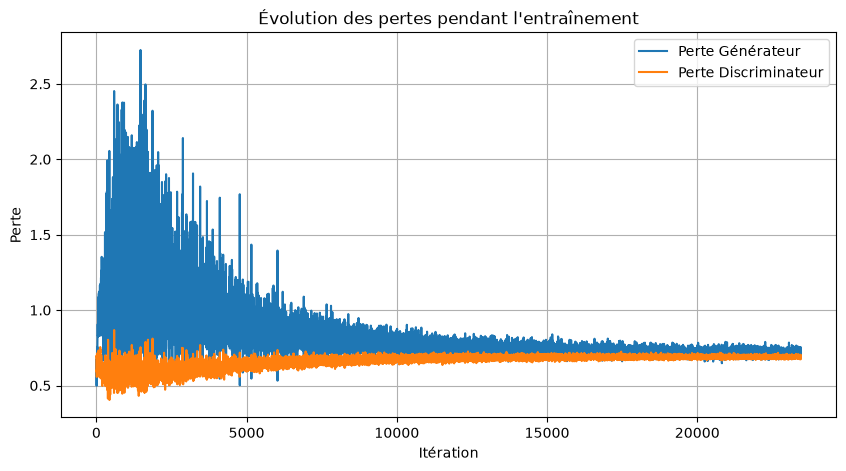

In [16]:
plt.figure(figsize=(10,5))
plt.plot(G_losses, label="Perte Générateur")
plt.plot(D_losses, label="Perte Discriminateur")
plt.xlabel("Itération")
plt.ylabel("Perte")
plt.title("Évolution des pertes pendant l'entraînement")
plt.legend()
plt.grid(True)
plt.show()

In [15]:
## 8. Génération finale et sauvegarde des modèles

# Nous sauvegardons les poids du générateur et du discriminateur.

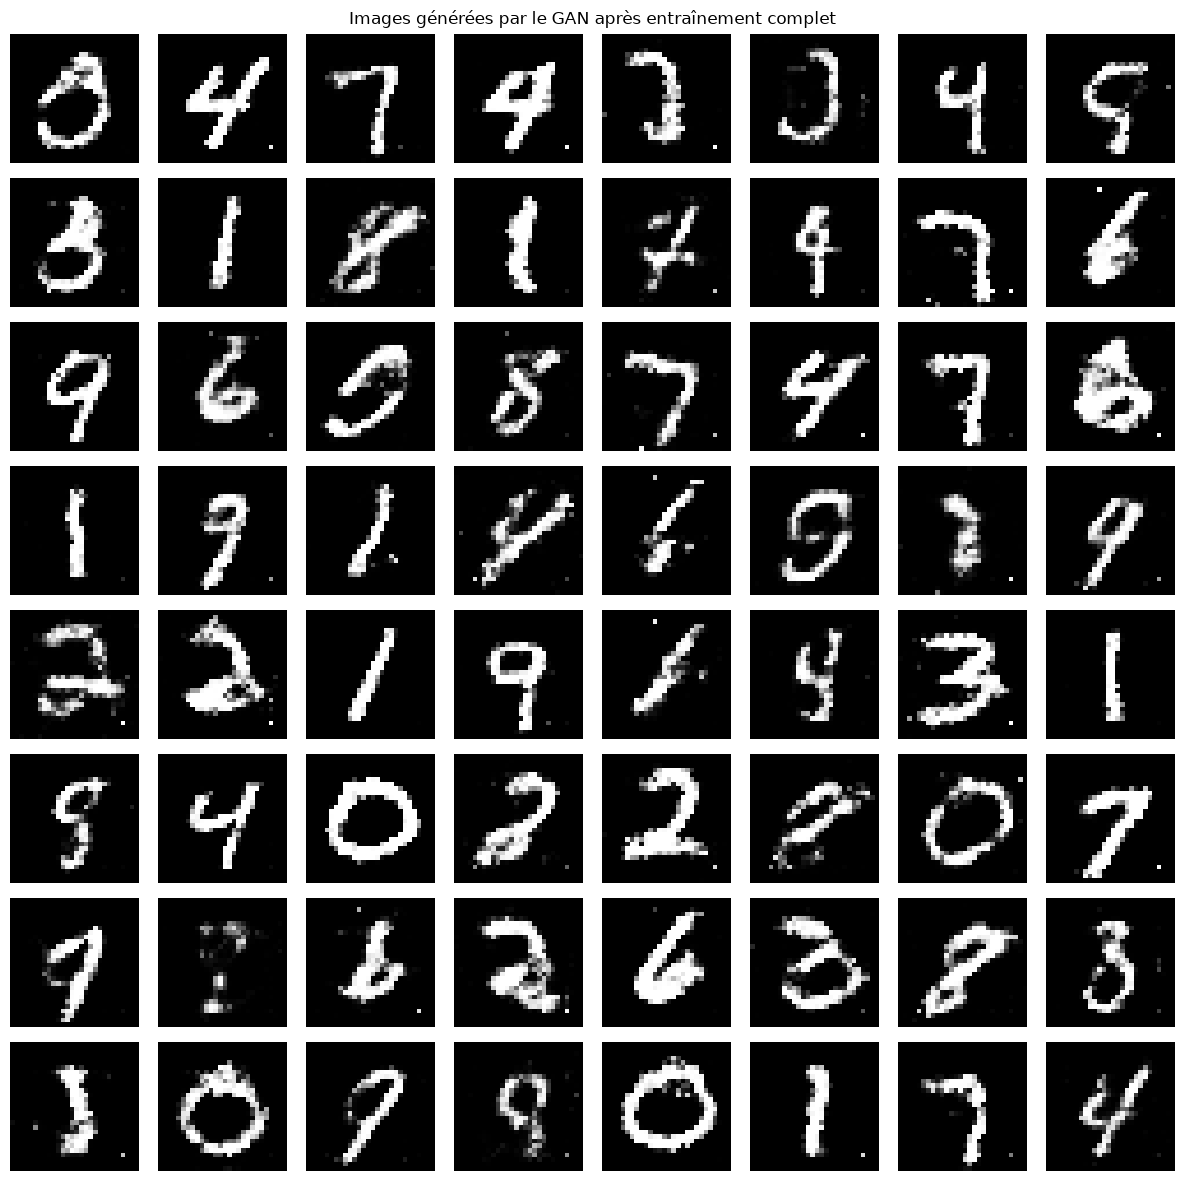

Modèles sauvegardés dans ../models/


In [17]:
# Génération de 64 échantillons finaux
gen.eval()
with torch.no_grad():
    sample_noise = torch.randn(64, latent_dim, device=device)
    generated = gen(sample_noise).cpu()

# Affichage 8x8
fig, axes = plt.subplots(8, 8, figsize=(12, 12))
for i, ax in enumerate(axes.flat):
    ax.imshow(generated[i].squeeze(), cmap='gray')
    ax.axis('off')
plt.suptitle("Images générées par le GAN après entraînement complet")
plt.tight_layout()
plt.show()

# Sauvegarde
os.makedirs("../models", exist_ok=True)
torch.save(gen.state_dict(), "../models/gan_generator_mnist.pth")
torch.save(disc.state_dict(), "../models/gan_discriminator_mnist.pth")
print("Modèles sauvegardés dans ../models/")

In [1]:
## 9. Conclusion

# Ce GAN simple montre des résultats souvent **flous** ou **effondrés** (mode collapse).  
# C'est la limite classique des GANs. Dans le notebook suivant (04_wgangp), nous implémenterons **WGAN avec Gradient Penalty** pour améliorer la stabilité et la qualité des générations.

In [2]:
print(f"Perte Générateur finale : {g_loss_final:.4f}")
print(f"Perte Discriminateur finale : {d_loss_final:.4f}")

NameError: name 'g_loss_final' is not defined